# 헤이즐넛 이미지 분류하기

### 라이브러리 불러오기

In [1]:
import os
import cv2
import tarfile
import urllib.request
import numpy as np
import matplotlib.pyplot as plt 
import koreanize_matplotlib

from skimage.feature import hog
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

### 데이터 다운받기

In [2]:
# hazelnut 카테고리 다운로드 링크
hazelnut_URL = 'https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f283/download/420937545-1629959162/hazelnut.tar.xz'

# 압축 파일 저장 위치
archive_path = "./content/hazelnut_correct.tar.xz"

# 압축 해제 루트 경로
extract_root = "./content"

# 최종 데이터셋 폴더 경로
dataset_dir = "./content/hazelnut"

expected_train_good = os.path.join(dataset_dir, "train", "good")
bottle_like = (
    os.path.exists(os.path.join(dataset_dir, "ground_truth", "broken_large"))
    or os.path.exists(os.path.join(dataset_dir, "ground_truth", "broken_small"))
)
need_download = (not os.path.exists(expected_train_good)) or bottle_like

if need_download:
    # 이전에 잘못 받은 tar가 풀려서 폴더가 남아있을 수 있으므로 정리 후 다시 받습니다.
    if os.path.exists(dataset_dir):
        import shutil
        shutil.rmtree(dataset_dir, ignore_errors=True)

    print("hazelnut 데이터 다운로드/압축 해제 시작...")
    urllib.request.urlretrieve(hazelnut_URL, archive_path)
    print("다운로드 완료:", archive_path)

    print("압축 해제 시작...")
    with tarfile.open(archive_path, "r:xz") as tar:
        tar.extractall(path=extract_root)
    print("압축 해제 완료:", dataset_dir)
else:
    print("이미 hazelnut 데이터가 준비되어 있습니다:", dataset_dir)

# 현재 /content 폴더 일부 확인
print("현재 /content 폴더 목록 일부:", os.listdir("./content")[:20])

이미 hazelnut 데이터가 준비되어 있습니다: ./content/hazelnut
현재 /content 폴더 목록 일부: ['hazelnut', 'hazelnut_correct.tar.xz']


In [3]:
# 데이터셋 경로와 분석 이미지 크기 설정

# 사용할 데이터셋 폴더
DATASET_DIR = "./content/hazelnut"

# HOG 특징 추출 전에 모든 이미지를 이 크기로 맞춤
IMG_SIZE = (128, 128)

### HOG 특징 추출 함수 만들기

In [4]:
def extract_hog_feature(image_path, size=(128, 128)):

    # 이미지 읽기 (OpenCV는 기본적으로 BGR 순서로 읽음)
    img = cv2.imread(image_path)

    # 이미지가 없거나 읽기에 실패하면 None 반환
    if img is None:
        return None, None, None

    # 화면에 보여주기 위해 RGB로 변환
    original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 특징 추출 전에 모든 이미지를 같은 크기로 맞춤
    resized = cv2.resize(img, size)

    # HOG는 흑백 영상 기반으로 특징을 계산
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # HOG 특징 추출
    feature = hog(
        gray,
        orientations=9,          # gradient 방향 구간 수
        pixels_per_cell=(16, 16),  # 셀 크기
        cells_per_block=(2, 2),  # 블록 크기
        block_norm="L2-Hys"      # 정규화 방식
    )

    return feature, original_rgb, gray

### 정상 학습 이미지 불러오기

In [5]:
# 정상 학습 이미지가 들어 있는 폴더
train_good_dir = os.path.join(DATASET_DIR, "train", "good")

# 특징 벡터를 저장할 리스트
X_train = []

# 학습 이미지 경로를 저장할 리스트
train_paths = []

# 폴더 안의 이미지들을 순서대로 읽음
for fname in sorted(os.listdir(train_good_dir)):
    fpath = os.path.join(train_good_dir, fname)

    # 이미지 1장마다 HOG 특징 추출
    feat, _, _ = extract_hog_feature(fpath, IMG_SIZE)

    # 정상적으로 특징이 추출된 경우만 저장
    if feat is not None:
        X_train.append(feat)
        train_paths.append(fpath)

# 리스트를 numpy 배열로 변환
X_train = np.array(X_train)

print("정상 학습 이미지 수:", len(X_train))
print("특징 벡터 shape:", X_train.shape)

정상 학습 이미지 수: 391
특징 벡터 shape: (391, 1764)


### 학습 이미지 일부 시각화

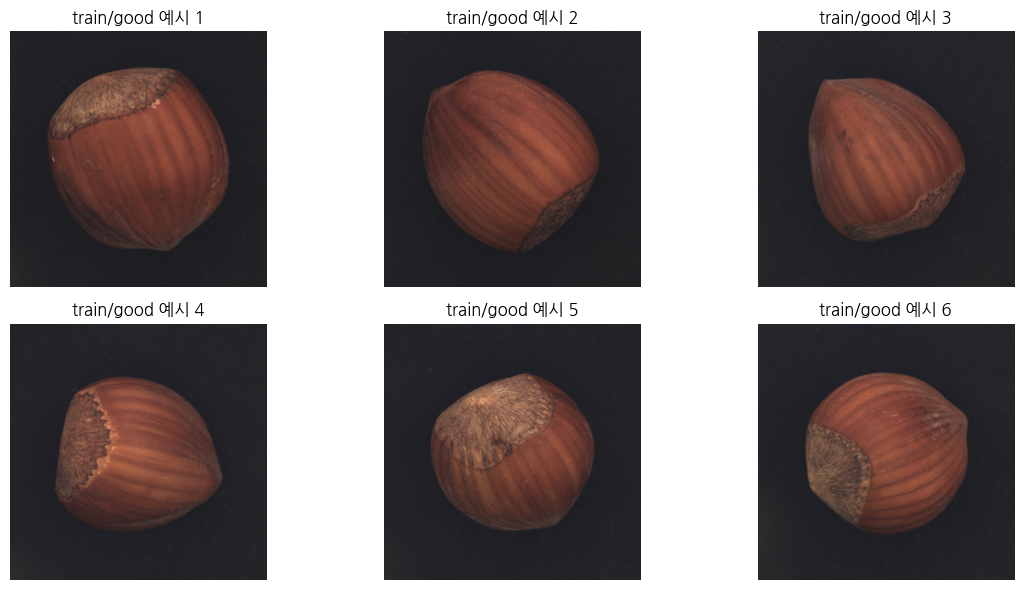

In [6]:
sample_count = min(6, len(train_paths))

plt.figure(figsize=(12, 6))

for i in range(sample_count):
    img = cv2.imread(train_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"train/good 예시 {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Isolation Forest 모델 학습

In [7]:
# 특징 벡터 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 모델 학습
model = IsolationForest(
        n_estimators=500,
        contamination='auto',
        max_features=1.0,
        max_samples=0.8,
        random_state=42)

# 정상 데이터 특징만 사용하여 학습
model.fit(X_train_scaled)

print("정상 패턴 학습 완료")

정상 패턴 학습 완료


### train_scores 계산 + 테스트 데이터 로딩 + test_scores 계산

In [8]:
# 정상 학습 이미지들의 정상성 점수 계산
train_scores = model.decision_function(X_train_scaled)

# 테스트 데이터 불러오기
# 테스트 데이터가 들어 있는 폴더
test_dir = os.path.join(DATASET_DIR, "test")

# 테스트 특징 벡터
X_test = []

# 실제 정답 라벨 저장 (정상=0, 이상=1)
y_true = []

# 테스트 파일 경로 저장
test_paths = []

# 결함 유형(폴더명) 저장
defect_types = []

# test 폴더 아래의 하위 폴더를 순회
for defect_type in sorted(os.listdir(test_dir)):
    defect_path = os.path.join(test_dir, defect_type)

    # 폴더가 아닌 경우는 건너뜀
    if not os.path.isdir(defect_path):
        continue

    # 해당 결함 폴더 안의 이미지들을 순회
    for fname in sorted(os.listdir(defect_path)):
        fpath = os.path.join(defect_path, fname)

        # HOG 특징 추출
        feat, _, _ = extract_hog_feature(fpath, IMG_SIZE)

        # 정상적으로 특징 추출에 성공한 경우 저장
        if feat is not None:
            X_test.append(feat)
            test_paths.append(fpath)
            defect_types.append(defect_type)

            # good 폴더면 정상(0), 아니면 이상(1)
            if defect_type == "good":
                y_true.append(0)
            else:
                y_true.append(1)

# numpy 배열로 변환
X_test = np.array(X_test)
y_true = np.array(y_true)

# X_test 정규화
X_test_scaled  = scaler.transform(X_test)

# 테스트 이미지들의 정상성 점수 계산
test_scores = model.decision_function(X_test_scaled)

print("테스트 이미지 수:", len(X_test))
print("정상 수:", np.sum(y_true == 0))
print("이상 수:", np.sum(y_true == 1))

테스트 이미지 수: 110
정상 수: 40
이상 수: 70


### percentile 비교 후 threshold percentile 조정

In [9]:
print(f"{'percentile':>10} | {'threshold':>10} | {'precision':>10} | {'recall':>10} | {'f1':>6}")
print("-" * 65)

for p in range(0, 101, 5):
    thr = np.percentile(train_scores, p)
    pred = (test_scores < thr).astype(int)    
    prec = precision_score(y_true, pred, zero_division=0)
    rec  = recall_score(y_true, pred, zero_division=0)
    f1   = f1_score(y_true, pred, zero_division=0)
    
    print(f"{p:>10} | {thr:>10.4f} | {prec:>10.3f} | {rec:>10.3f} | {f1:>8.3f}")

percentile |  threshold |  precision |     recall |     f1
-----------------------------------------------------------------
         0 |    -0.0056 |      1.000 |      0.014 |    0.028
         5 |     0.0297 |      0.933 |      0.200 |    0.329
        10 |     0.0348 |      0.850 |      0.243 |    0.378
        15 |     0.0391 |      0.833 |      0.286 |    0.426
        20 |     0.0424 |      0.765 |      0.371 |    0.500
        25 |     0.0451 |      0.737 |      0.400 |    0.519
        30 |     0.0486 |      0.745 |      0.500 |    0.598
        35 |     0.0503 |      0.741 |      0.571 |    0.645
        40 |     0.0528 |      0.731 |      0.700 |    0.715
        45 |     0.0539 |      0.731 |      0.700 |    0.715
        50 |     0.0555 |      0.729 |      0.729 |    0.729
        55 |     0.0580 |      0.738 |      0.843 |    0.787
        60 |     0.0602 |      0.723 |      0.857 |    0.784
        65 |     0.0621 |      0.722 |      0.929 |    0.812
        70 |     0.06

In [10]:
# f1 기준 최적값으로 threshold 설정
threshold = np.percentile(train_scores, 65)
print(f"최종 threshold: {threshold:.4f} (percentile=65)")

최종 threshold: 0.0621 (percentile=65)


### 테스트 이미지 정상/이상 판별

In [11]:
# threshold보다 작으면 이상(1), 아니면 정상(0)
y_pred = (test_scores < threshold).astype(int)

print("예측 완료")

예측 완료


In [12]:
# 성능 확인
print("Confusion Matrix")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=["normal", "anomaly"]))

Confusion Matrix
[[15 25]
 [ 5 65]]

Classification Report
              precision    recall  f1-score   support

      normal       0.75      0.38      0.50        40
     anomaly       0.72      0.93      0.81        70

    accuracy                           0.73       110
   macro avg       0.74      0.65      0.66       110
weighted avg       0.73      0.73      0.70       110



In [13]:
# 결함 유형별 성능 분석
print(f"{'결함 유형':>7} | {'전체':>5} | {'정탐':>5} | {'검출률(recall)':>14}")
print("-" * 48)

for dtype in sorted(set(defect_types)):
    idxs = [i for i, d in enumerate(defect_types) if d == dtype]
    true = [y_true[i] for i in idxs]
    pred = [y_pred[i] for i in idxs]
    
    total = len(idxs)
    if dtype == 'good':
        # 정상은 정상으로 맞춘 수
        correct = sum(1 for t, p in zip(true, pred) if t == 0 and p == 0)
        print(f"{'good':>10} | {total:>6} | {correct:>6} | {correct/total:>14.3f}")
    else:
        # 이상은 이상으로 맞춘 수
        detected = sum(1 for t, p in zip(true, pred) if t == 1 and p == 1)
        print(f"{dtype:>10} | {total:>6} | {detected:>6} | {detected/total:>14.3f}")

  결함 유형 |    전체 |    정탐 |    검출률(recall)
------------------------------------------------
     crack |     18 |     18 |          1.000
       cut |     17 |     16 |          0.941
      good |     40 |     15 |          0.375
      hole |     18 |     15 |          0.833
     print |     17 |     16 |          0.941


### 결과 시각화

In [14]:
# 결과 시각화 함수 만들기
def show_results(paths, scores, y_true, y_pred, defect_types, n=12):

    # 전체 이미지 수보다 n이 크면 실제 개수까지만 사용
    count = min(n, len(paths))

    # 전체 범위에서 균등하게 샘플 선택
    idxs = np.linspace(0, len(paths) - 1, count, dtype=int)

    plt.figure(figsize=(16, 12))

    for i, idx in enumerate(idxs, 1):
        # 이미지 읽기
        img = cv2.imread(paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 정답과 예측을 한글로 변환
        gt = "정상" if y_true[idx] == 0 else "이상"
        pred = "정상" if y_pred[idx] == 0 else "이상"

        plt.subplot(3, 4, i)
        plt.imshow(img)
        plt.title(f"{defect_types[idx]}\nGT: {gt} / Pred: {pred}\nScore: {scores[idx]:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

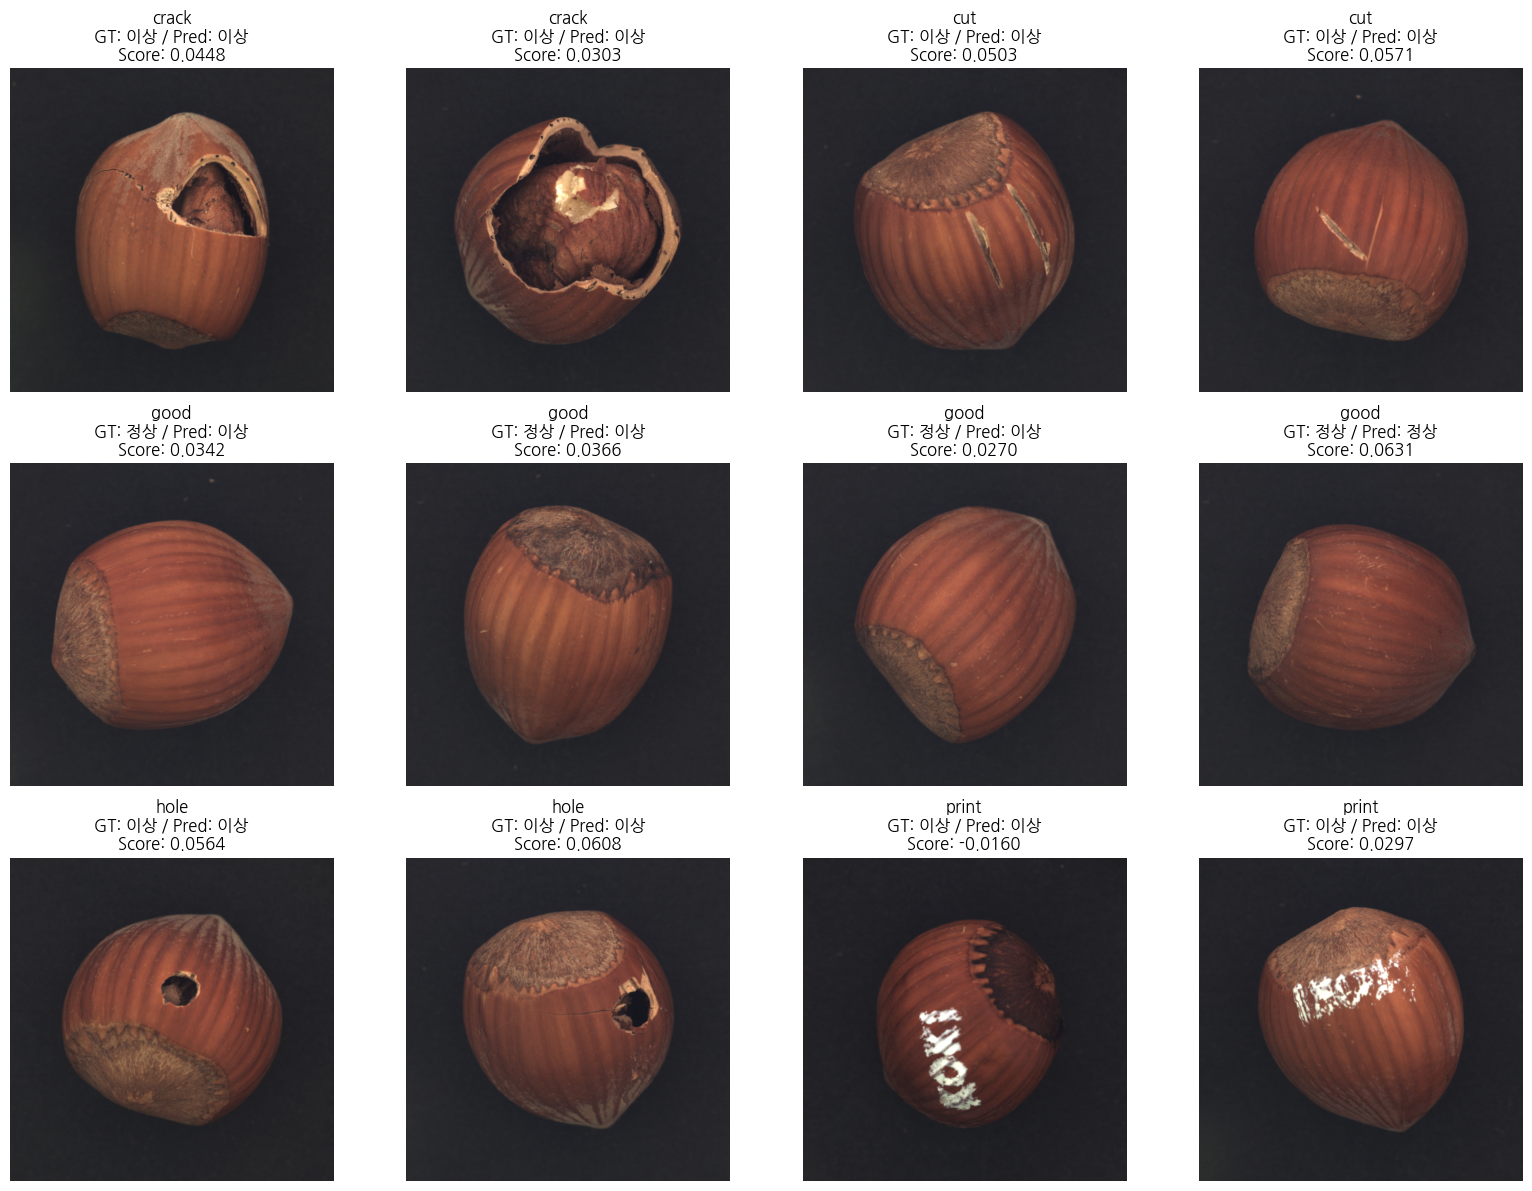

In [15]:
# 테스트 결과 일부 확인
show_results(test_paths, test_scores, y_true, y_pred, defect_types, n=12)

### OpenCV 후처리로 이상 위치 박스 표시 - 정상 참조 이미지 1장

회전 차이로 오탐 많음

검출된 박스 수: 5
박스: (110, 129, 53, 51, 1309.0)
박스: (79, 127, 23, 50, 572.0)
박스: (116, 86, 38, 39, 431.0)
박스: (45, 41, 65, 61, 915.5)
박스: (126, 35, 77, 98, 1770.0)


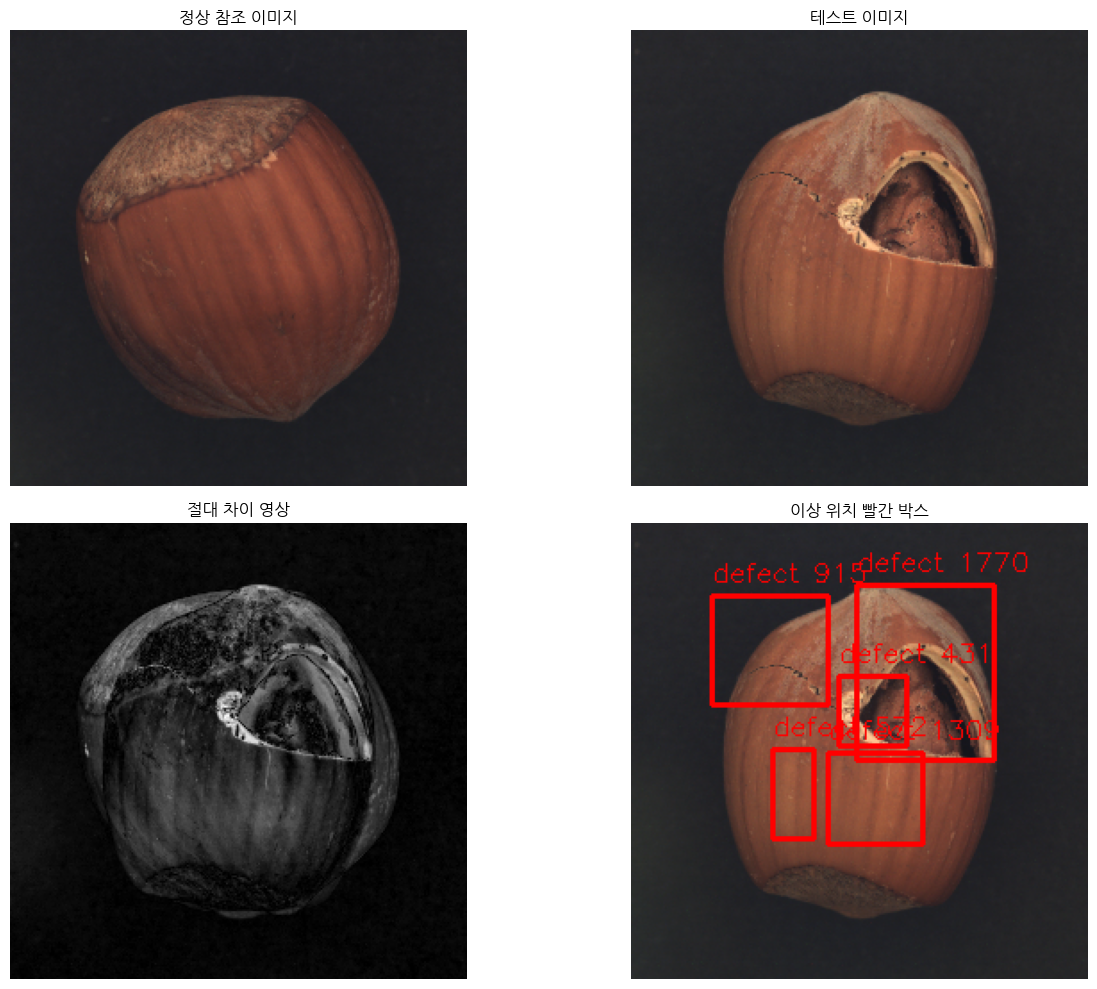

In [16]:
def localize_anomaly_with_reference(reference_path, test_path,
                                    resize=(256, 256),
                                    diff_thresh=30,
                                    min_area=80):

    # 1) 이미지 읽기
    ref = cv2.imread(reference_path)
    test = cv2.imread(test_path)

    if ref is None or test is None:
        raise ValueError("참조 이미지 또는 테스트 이미지를 읽을 수 없습니다.")

    # 2) 동일한 크기로 맞춤
    ref = cv2.resize(ref, resize)
    test = cv2.resize(test, resize)

    # 시각화용 RGB 변환
    ref_rgb = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
    test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

    # 3) 흑백 변환 후 절대 차이 계산
    ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)
    diff_gray = cv2.absdiff(ref_gray, test_gray)

    # 4) 차이가 큰 부분만 남기기
    _, binary = cv2.threshold(diff_gray, diff_thresh, 255, cv2.THRESH_BINARY)

    # 5) morphology로 노이즈 제거 및 연결
    kernel = np.ones((5, 5), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 6) 윤곽선 찾기 (RETR_TREE: 계층 구조 포함)
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxed = test.copy()
    boxes = []

    if hierarchy is not None:
        hierarchy = hierarchy[0]

        for i, cnt in enumerate(contours):
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue

            parent = hierarchy[i][3]
            x, y, w, h = cv2.boundingRect(cnt)
            boxes.append((x, y, w, h, area))

            if parent == -1:
                color = (0, 0, 255)       # 빨강 — 주요 결함
                label = f"defect {int(area)}"
            else:
                color = (0, 255, 255)     # 노랑 — 내부 윤곽
                label = f"inner {int(area)}"

            cv2.rectangle(boxed, (x, y), (x + w, y + h), color, 2)
            cv2.putText(boxed, label, (x, max(y - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    boxed_rgb = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)
    return ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes


# 정상 참조 이미지 1장 선택
reference_path = train_paths[0]

# 테스트 이미지 중 실제 이상 샘플만 추출
anomaly_candidates = [p for p, label in zip(test_paths, y_true) if label == 1]

if len(anomaly_candidates) == 0:
    raise ValueError("이상 샘플이 없습니다. 다른 카테고리를 사용해 보세요.")

sample_anomaly_path = anomaly_candidates[0]

# 후처리 실행
ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes = localize_anomaly_with_reference(
    reference_path,
    sample_anomaly_path,
    resize=(256, 256),
    diff_thresh=30,
    min_area=80
)

print("검출된 박스 수:", len(boxes))
for b in boxes:
    print("박스:", b)

# 시각화
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(ref_rgb)
plt.title("정상 참조 이미지")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(test_rgb)
plt.title("테스트 이미지")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(diff_gray, cmap="gray")
plt.title("절대 차이 영상")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(boxed_rgb)
plt.title("이상 위치 빨간 박스")
plt.axis("off")

plt.tight_layout()
plt.show()

### OpenCV 후처리로 이상 위치 박스 표시 - 정상 참조 이미지 50장 평균

디테일 손실로 차이맵 부정확

 → 결론: 헤이즐넛처럼 회전 변동이 큰 데이터는 단순 픽셀 차이 비교 방식의 한계가 있음

검출된 박스 수: 3
박스: (116, 94, 13, 18, 118.0)
박스: (129, 86, 24, 39, 288.0)
박스: (108, 35, 95, 97, 2679.0)


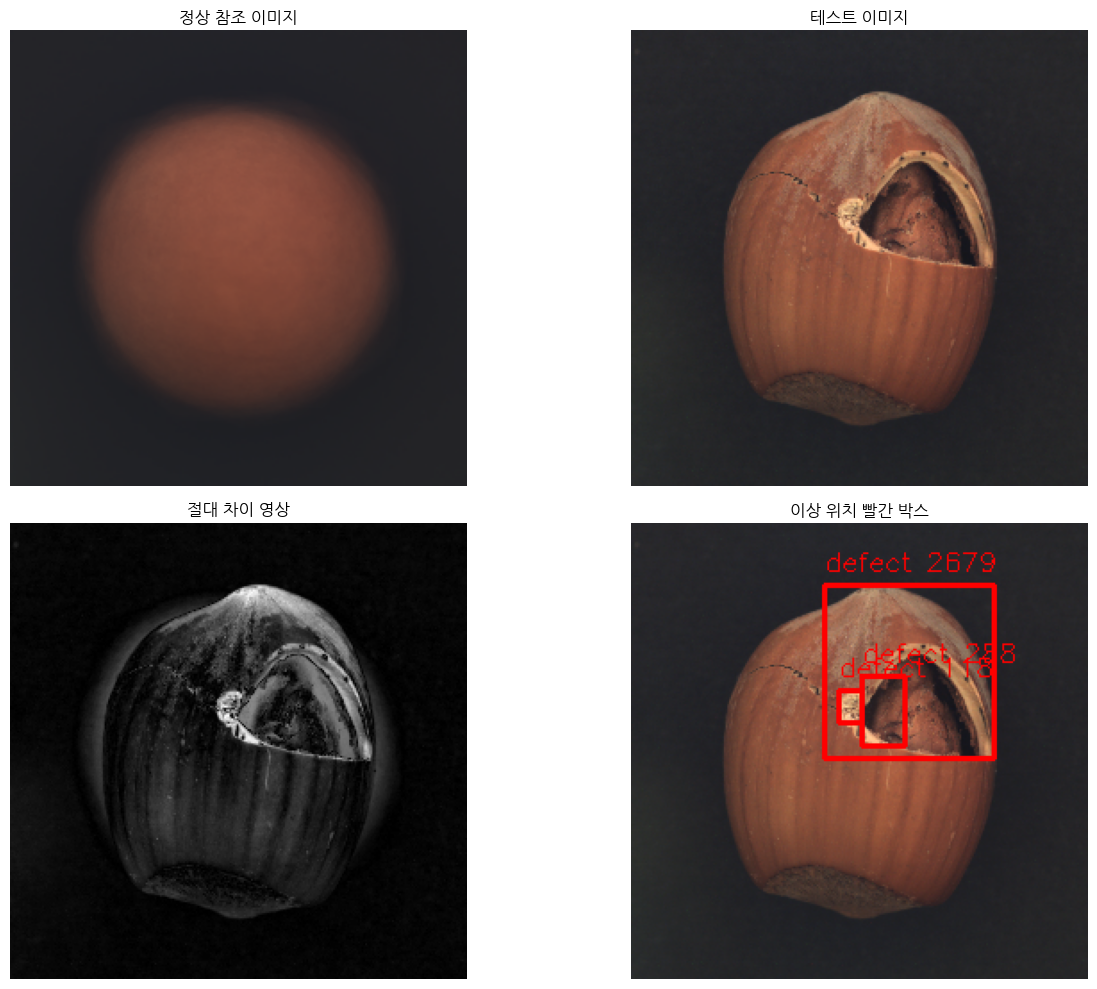

In [17]:
def localize_anomaly_with_reference(reference, test_path,
                                    resize=(256, 256),
                                    diff_thresh=30,
                                    min_area=80):

    # 1) 이미지 읽기 — 경로(str)면 읽고, 배열이면 그대로 사용
    if isinstance(reference, str):
        ref = cv2.imread(reference)
    else:
        ref = reference.copy()  # 이미 numpy 배열인 경우

    test = cv2.imread(test_path)

    # 읽기에 실패하면 예외 발생
    if ref is None or test is None:
        raise ValueError("참조 이미지 또는 테스트 이미지를 읽을 수 없습니다.")

    # 2) 비교를 위해 동일한 크기로 맞춤
    ref = cv2.resize(ref, resize)
    test = cv2.resize(test, resize)

    # 시각화용 RGB 변환
    ref_rgb = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
    test_rgb = cv2.cvtColor(test, cv2.COLOR_BGR2RGB)

    # 3) 절대 차이 계산을 위해 흑백으로 변환
    ref_gray = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    test_gray = cv2.cvtColor(test, cv2.COLOR_BGR2GRAY)

    # 두 이미지의 픽셀 차이 계산
    diff_gray = cv2.absdiff(ref_gray, test_gray)

    # 4) 차이가 큰 부분만 남기기
    _, binary = cv2.threshold(diff_gray, diff_thresh, 255, cv2.THRESH_BINARY)

    # 5) morphology로 노이즈 제거 및 연결
    kernel = np.ones((5, 5), np.uint8)

    # 작은 점 잡음 제거
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 끊긴 영역 연결
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 6) 윤곽선 찾기
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    boxed = test.copy()
    boxes = []

    if hierarchy is not None:
        hierarchy = hierarchy[0]  # shape (1, N, 4) → (N, 4)

        for i, cnt in enumerate(contours):
            area = cv2.contourArea(cnt)
            if area < min_area:
                continue

            parent = hierarchy[i][3]  # -1이면 최상위(바깥 경계)

            x, y, w, h = cv2.boundingRect(cnt)
            boxes.append((x, y, w, h, area))

            if parent == -1:
                # 최상위 윤곽선 → 빨간 박스 (주요 결함 영역)
                color = (0, 0, 255)
                label = f"defect {int(area)}"
            else:
                # 내부 윤곽선 → 노란 박스 (구멍 내부 등)
                color = (0, 255, 255)
                label = f"inner {int(area)}"

            cv2.rectangle(boxed, (x, y), (x + w, y + h), color, 2)
            cv2.putText(boxed, label, (x, max(y - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    # OpenCV BGR → matplotlib RGB
    boxed_rgb = cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB)

    return ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes

# 공개 데이터의 이상 샘플에 대해 박스 표시
# 정상 이미지 여러 장 평균으로 참조 이미지 생성
def make_mean_reference(train_paths, resize=(256, 256), n=50):
    imgs = []
    for p in train_paths[:n]:
        img = cv2.imread(p)
        img = cv2.resize(img, resize)
        imgs.append(img.astype(np.float32))
    mean_img = np.mean(imgs, axis=0).astype(np.uint8)
    return mean_img

mean_ref = make_mean_reference(train_paths, resize=(256, 256), n=50)

# 테스트 이미지 중 실제 이상 샘플만 추출
anomaly_candidates = [p for p, label in zip(test_paths, y_true) if label == 1]

if len(anomaly_candidates) == 0:
    raise ValueError("이상 샘플이 없습니다. 다른 카테고리를 사용해 보세요.")

# 첫 번째 이상 샘플 선택
sample_anomaly_path = anomaly_candidates[0]

# 후처리 실행
ref_rgb, test_rgb, diff_gray, binary, boxed_rgb, boxes = localize_anomaly_with_reference(
    mean_ref,        # 단일 이미지 대신 평균 이미지, 경로 대신 배열 직접 전달
    sample_anomaly_path,
    resize=(256, 256),
    diff_thresh=30,
    min_area=80
)

print("검출된 박스 수:", len(boxes))
for b in boxes:
    print("박스:", b)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(ref_rgb)
plt.title("정상 참조 이미지")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(test_rgb)
plt.title("테스트 이미지")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(diff_gray, cmap="gray")
plt.title("절대 차이 영상")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(boxed_rgb)
plt.title("이상 위치 빨간 박스")
plt.axis("off")

plt.tight_layout()
plt.show()

### 발표 시각화 자료

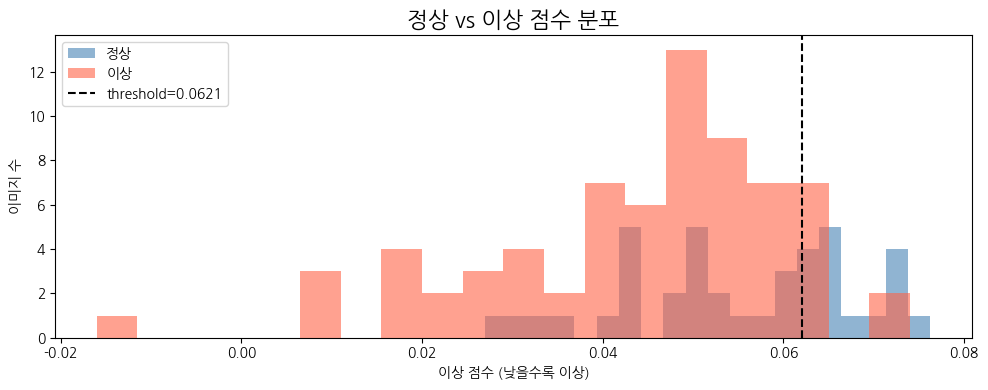

In [18]:
# 정상 vs 이상 점수 분포 비교: 분포가 겹칠수록 HOG 구분력이 낮음
normal_scores  = test_scores[y_true == 0]
anomaly_scores = test_scores[y_true == 1]

plt.figure(figsize=(10, 4))
plt.hist(normal_scores,  bins=20, alpha=0.6, label='정상', color='steelblue')
plt.hist(anomaly_scores, bins=20, alpha=0.6, label='이상', color='tomato')
plt.axvline(threshold, color='black', linestyle='--', label=f'threshold={threshold:.4f}')
plt.xlabel('이상 점수 (낮을수록 이상)')
plt.ylabel('이미지 수')
plt.title('정상 vs 이상 점수 분포', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

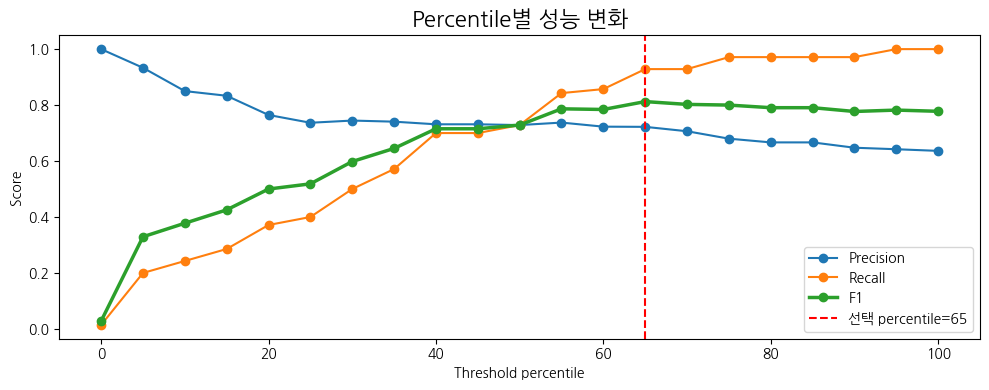

In [19]:
# percentile별 지표 꺾은선 그래프
# percentile 선택 근거 → F1이 70에서 최고점, 이후 precision 급락

ps = list(range(0, 101, 5))
precs, recs, f1s = [], [], []

for p in ps:
    thr = np.percentile(train_scores, p)
    pred = (test_scores < thr).astype(int)
    precs.append(precision_score(y_true, pred, zero_division=0))
    recs.append(recall_score(y_true, pred, zero_division=0))
    f1s.append(f1_score(y_true, pred, zero_division=0))

plt.figure(figsize=(10, 4))
plt.plot(ps, precs, marker='o', label='Precision')
plt.plot(ps, recs,  marker='o', label='Recall')
plt.plot(ps, f1s,   marker='o', label='F1', linewidth=2.5)
plt.axvline(65, color='red', linestyle='--', label='선택 percentile=65')
plt.xlabel('Threshold percentile')
plt.ylabel('Score')
plt.title('Percentile별 성능 변화', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

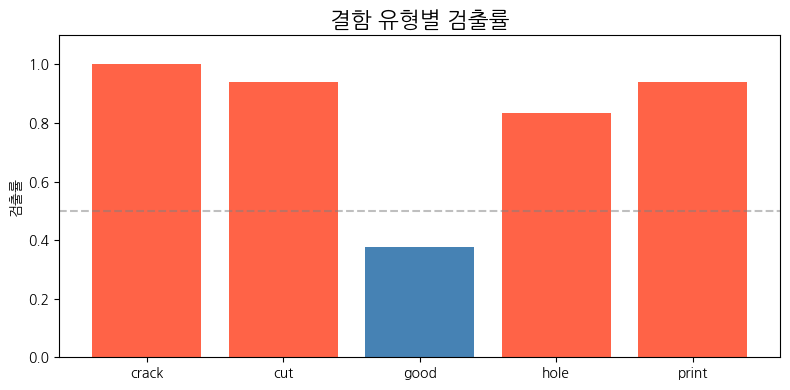

In [20]:
# 결함 유형별 검출률 막대그래프
# 결함 유형별 검출률: crack/cut은 잘 잡힘, rot/print는 낮음 → HOG 한계

# 결함 유형별 recall 계산
dtype_recalls = {}
for dtype in sorted(set(defect_types)):
    idxs = [i for i, d in enumerate(defect_types) if d == dtype]
    true = [y_true[i] for i in idxs]
    pred = [y_pred[i] for i in idxs]
    if dtype == 'good':
        # 정상은 정상으로 맞춘 비율 (specificity)
        correct = sum(1 for t, p in zip(true, pred) if t == 0 and p == 0)
        dtype_recalls[dtype] = correct / len(idxs)
    else:
        detected = sum(1 for t, p in zip(true, pred) if t == 1 and p == 1)
        dtype_recalls[dtype] = detected / len(idxs)

plt.figure(figsize=(8, 4))
colors = ['steelblue' if k == 'good' else 'tomato' for k in dtype_recalls]
plt.bar(dtype_recalls.keys(), dtype_recalls.values(), color=colors)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1)
plt.ylabel('검출률')
plt.title('결함 유형별 검출률', fontsize=16)
plt.tight_layout()
plt.show()

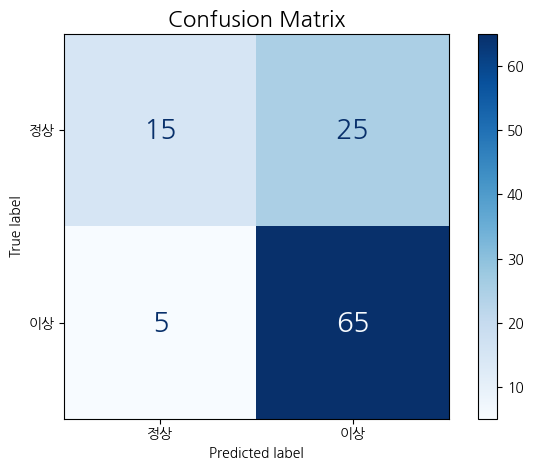

In [ ]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=["정상", "이상"],
    cmap="Blues",
    text_kw={"fontsize": 20}  # Matrix 내부 글씨 크기
)

plt.title("Confusion Matrix", fontsize=16)
plt.tight_layout()
plt.show()

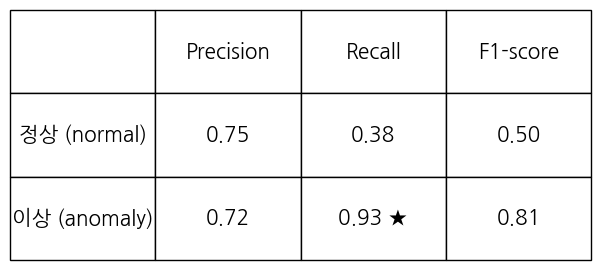

In [ ]:
# normal, anomaly 관련 수치
fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('off')

data = [['', 'Precision', 'Recall', 'F1-score'],
        ['정상 (normal)', '0.75', '0.38', '0.50'],
        ['이상 (anomaly)', '0.72', '0.93 ★', '0.81']]

table = ax.table(cellText=data[1:], colLabels=data[0], loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(15)
table.scale(1.5, 5)

plt.show()